In [1]:
!pip install pytorch-fid
!pip install scikit-learn torchmetrics scipy
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00


In [2]:
# <<< THAY ĐỔI: Chạy dòng này trước tiên để cài đặt thư viện cần thiết
# !pip install lpips

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import umap
from itertools import product
import lpips # <<< THAY ĐỔI: Import thư viện lpips

# ==============================================================================
# 1. Cấu hình và Thiết lập (Configuration and Setup)
# ==============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "results_wae_annealing_v4_lpips" # <<< THAY ĐỔI: Đổi tên thư mục kết quả
os.makedirs(SAVE_DIR, exist_ok=True)

config = {
    "latent_dim": 32,
    "n_classes": 10,
    "batch_size": 128,
    "epochs": 50,
    "lr": 1e-3,
    "rho_prior": 0.7,
    "epsilon": 1e-8,
    # --- Cấu hình cho Loss ---
    "bce_weight": 0.3,      # <<< THAY ĐỔI: Trọng số cho BCE loss
    "lpips_weight": 0.7,    # <<< THAY ĐỔI: Trọng số cho LPIPS loss
    # --- Cấu hình cho Annealing ---
    "sup_mmd_weight": 20.0,
    "unsup_mmd_weight": 50.0,
    "anneal_epochs": 20,
}

# ==============================================================================
# 2. Các hàm tiện ích (Không thay đổi)
# ==============================================================================
def sample_uniform_sphere(n_samples, dim, device=DEVICE):
    eta = torch.randn(n_samples, dim, device=device)
    return F.normalize(eta, p=2, dim=1)

def mobius_reparam(eps, mu, rho):
    rho = rho.unsqueeze(-1) if rho.dim() == 1 else rho
    eps_mu_dot = torch.sum(eps * mu, dim=1, keepdim=True)
    numerator = (1 - rho**2) * eps + 2 * rho**2 * mu + 2 * rho * eps_mu_dot * mu
    denominator = 1 + 2 * rho * eps_mu_dot + rho**2
    z = numerator / (denominator + config["epsilon"])
    return F.normalize(z, p=2, dim=1)

def rbf_kernel(x, y, sigma):
    dist_sq = 2 - 2 * (x @ y.t())
    return torch.exp(-dist_sq / (2 * sigma**2 + config["epsilon"]))

def mmd_loss(q_samples, p_samples, sigma=None):
    if q_samples.shape[0] < 2 or p_samples.shape[0] < 2:
        return torch.tensor(0.0, device=DEVICE)
    if sigma is None:
        with torch.no_grad():
            dists = torch.pdist(torch.cat([q_samples, p_samples], dim=0))
            sigma = dists.median()
    k_qq = rbf_kernel(q_samples, q_samples, sigma).mean()
    k_pp = rbf_kernel(p_samples, p_samples, sigma).mean()
    k_qp = rbf_kernel(q_samples, p_samples, sigma).mean()
    return k_qq + k_pp - 2 * k_qp

# ==============================================================================
# 3. Kiến trúc Mô hình (Không thay đổi)
# ==============================================================================
class EncoderCNN(nn.Module):
    def __init__(self, latent_dim):
        super(EncoderCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.fc_block = nn.Sequential(nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(True))
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_s = nn.Linear(256, 1)
    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return self.fc_mu(x), self.fc_s(x)

class DecoderCNN(nn.Module):
    def __init__(self, latent_dim):
        super(DecoderCNN, self).__init__()
        self.fc_block = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(True), nn.Linear(256, 128 * 4 * 4), nn.ReLU(True))
        self.deconv_block = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), nn.Sigmoid()
        )
    def forward(self, z):
        x = self.fc_block(z)
        x = x.view(-1, 128, 4, 4)
        return self.deconv_block(x)

class SphericalWAE_Supervised(nn.Module):
    def __init__(self, latent_dim, n_classes):
        super(SphericalWAE_Supervised, self).__init__()
        self.encoder = EncoderCNN(latent_dim)
        self.decoder = DecoderCNN(latent_dim)
        self.prior_mus = nn.Parameter(torch.randn(n_classes, latent_dim))
        self.rho_p = config["rho_prior"]
    def encode_to_distribution(self, x):
        mu_q_unnormalized, s_q = self.encoder(x)
        mu_q = F.normalize(mu_q_unnormalized, p=2, dim=1)
        rho_q = torch.sigmoid(s_q).squeeze(-1) * (1 - config["epsilon"])
        return mu_q, rho_q
    def forward(self, x):
        mu_q, rho_q = self.encode_to_distribution(x)
        eps = sample_uniform_sphere(x.shape[0], config["latent_dim"], device=x.device)
        z_q = mobius_reparam(eps, mu_q, rho_q)
        x_hat = self.decoder(z_q)
        return x_hat, z_q

# ==============================================================================
# 4. Hàm tính toán Mất mát (<<< PHẦN CHỈNH SỬA CHÍNH)
# ==============================================================================
def calculate_loss(x, y, x_hat, z_q, model, loss_fn_vgg, sup_mmd_weight, unsup_mmd_weight):
    # --- Thành phần Tái tạo ---
    bce_loss = F.binary_cross_entropy(x_hat, x, reduction='mean')

    # Chuyển đổi thang đo của ảnh từ [0, 1] sang [-1, 1] cho LPIPS
    x_rescaled = (x * 2) - 1
    x_hat_rescaled = (x_hat * 2) - 1
    # LPIPS yêu cầu ảnh 3 kênh, ta lặp lại kênh màu xám 3 lần
    x_rescaled_rgb = x_rescaled.repeat(1, 3, 1, 1)
    x_hat_rescaled_rgb = x_hat_rescaled.repeat(1, 3, 1, 1)

    lpips_loss = loss_fn_vgg(x_hat_rescaled_rgb, x_rescaled_rgb).mean()

    # Kết hợp hai loss tái tạo
    recon_loss = config["bce_weight"] * bce_loss + config["lpips_weight"] * lpips_loss

    # --- Các thành phần MMD (giữ nguyên) ---
    supervised_mmd_loss = 0.0
    normalized_prior_mus = F.normalize(model.prior_mus, p=2, dim=1)
    for c in range(config["n_classes"]):
        class_mask = (y == c)
        if class_mask.sum() > 1:
            supervised_mmd_loss += mmd_loss(z_q[class_mask],
                                            mobius_reparam(sample_uniform_sphere(class_mask.sum(), config["latent_dim"]),
                                                           normalized_prior_mus[c].expand(class_mask.sum(), -1),
                                                           torch.full((class_mask.sum(),), model.rho_p, device=DEVICE)))
    supervised_mmd_loss /= config["n_classes"]

    random_classes = torch.randint(0, config["n_classes"], (x.size(0),), device=DEVICE)
    z_p_unsupervised = mobius_reparam(sample_uniform_sphere(x.size(0), config["latent_dim"]),
                                      normalized_prior_mus[random_classes],
                                      torch.full((x.size(0),), model.rho_p, device=DEVICE))
    unsupervised_mmd_loss = mmd_loss(z_q, z_p_unsupervised)

    # --- Loss tổng hợp ---
    total_loss = recon_loss + \
                 (sup_mmd_weight * supervised_mmd_loss) + \
                 (unsup_mmd_weight * unsupervised_mmd_loss)

    return total_loss, recon_loss, supervised_mmd_loss, unsupervised_mmd_loss

# ==============================================================================
# 5. Vòng lặp Huấn luyện
# ==============================================================================
def train_epoch(model, train_loader, optimizer, epoch, scheduler, loss_fn_vgg): # <<< THAY ĐỔI: Thêm loss_fn_vgg
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}")
    loss_acc, recon_acc, sup_mmd_acc, unsup_mmd_acc = 0.0, 0.0, 0.0, 0.0

    anneal_rate = min(1.0, (epoch + 1) / config["anneal_epochs"])
    current_sup_weight = config["sup_mmd_weight"] * anneal_rate
    current_unsup_weight = config["unsup_mmd_weight"] * anneal_rate

    for data, labels in pbar:
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        x_hat, z_q = model(data)

        # <<< THAY ĐỔI: Truyền loss_fn_vgg vào hàm loss
        loss, recon, sup_mmd, unsup_mmd = calculate_loss(data, labels, x_hat, z_q, model, loss_fn_vgg, current_sup_weight, current_unsup_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_acc += loss.item()
        recon_acc += recon.item()
        sup_mmd_acc += sup_mmd.item()
        unsup_mmd_acc += unsup_mmd.item()

        pbar.set_postfix({
            "Loss": f"{loss.item():.3f}", "Recon": f"{recon.item():.3f}",
            "SupMMD": f"{sup_mmd.item():.4f}", "UnsupMMD": f"{unsup_mmd.item():.4f}",
            "λ": f"{current_sup_weight:.2f}", "γ": f"{current_unsup_weight:.2f}"
        })

    scheduler.step()
    n_batches = len(train_loader)
    print(f"====> Epoch {epoch+1} Avg Loss: Total={loss_acc/n_batches:.4f}, Recon={recon_acc/n_batches:.4f}, SupMMD={sup_mmd_acc/n_batches:.4f}, UnsupMMD={unsup_mmd_acc/n_batches:.4f}")
    return loss_acc/n_batches, recon_acc/n_batches, sup_mmd_acc/n_batches, unsup_mmd_acc/n_batches

# ==============================================================================
# 6. Trực quan hóa và Hàm chính
# ==============================================================================
def plot_random_samples_from_priors(model, save_dir="."):
    print("Bắt đầu sinh ảnh ngẫu nhiên từ các tiên nghiệm...")
    model.eval()
    n_classes, latent_dim = config["n_classes"], config["latent_dim"]
    fig, axes = plt.subplots(n_classes, 8, figsize=(8 * 1.5, n_classes * 1.5))
    with torch.no_grad():
        normalized_prior_mus = F.normalize(model.prior_mus, p=2, dim=1)
        for c in range(n_classes):
            mu_p = normalized_prior_mus[c].expand(8, -1)
            rho_p = torch.full((8,), model.rho_p, device=DEVICE)
            eps = sample_uniform_sphere(8, latent_dim, device=DEVICE)
            z_p = mobius_reparam(eps, mu_p, rho_p)
            generated_images = model.decoder(z_p)
            for i, img in enumerate(generated_images):
                ax = axes[c, i]
                ax.imshow(img.cpu().squeeze(), cmap='gray')
                ax.axis('off')
                if i == 0:
                    ax.text(-10, 14, f'{c}', verticalalignment='center', horizontalalignment='right', fontsize=12, fontweight='bold')
    plt.suptitle("Ảnh sinh ngẫu nhiên từ các thành phần Tiên nghiệm (Annealing)")
    plt.savefig(f'{save_dir}/random_samples_from_priors.png')
    plt.close(fig)

def from_latent(net, vec):
    with torch.no_grad():
        net.eval()
        vec_tensor = torch.from_numpy(vec).unsqueeze(0).to(DEVICE).float()
        vec_tensor_normalized = F.normalize(vec_tensor, p=2, dim=1)
        return net.decoder(vec_tensor_normalized).cpu().numpy().reshape(28, 28)

def get_sampling_grid(net, grid):
    base = torch.randn(config["latent_dim"] - 2)
    image_list = [torch.from_numpy(from_latent(net, np.hstack([vec_2d, base.numpy()]))) for vec_2d in grid]
    return torch.stack(image_list).unsqueeze(1)

def plot_grid_samples(model, save_dir="."):
    print("Bắt đầu sinh ảnh từ lưới phẳng (phương pháp so sánh)...")
    grid_points = list(product(np.linspace(-1.5, 1.5, 8), np.linspace(-1.5, 1.5, 8)))
    results = get_sampling_grid(model, grid_points)
    fig = plt.figure(figsize=(10, 10))
    img_grid = make_grid(results, nrow=8)
    plt.imshow(img_grid.permute(1, 2, 0))
    plt.title("Ảnh sinh ra từ Lưới Phẳng (Grid Sampling)")
    plt.axis('off')
    plt.savefig(f'{save_dir}/grid_samples.png')
    plt.close(fig)

def plot_results(history, model, test_loader, save_dir="."):
    print("Bắt đầu vẽ biểu đồ và trực quan hóa kết quả...")
    fig = plt.figure(figsize=(12, 8))
    plt.plot([h[0] for h in history], label='Total Loss')
    plt.plot([h[1] for h in history], label='Reconstruction Loss')
    plt.plot([h[2] for h in history], label='Supervised MMD Loss')
    plt.plot([h[3] for h in history], label='Unsupervised MMD Loss')
    plt.title('Lịch sử Huấn luyện (WAE with Annealing)')
    plt.xlabel('Epoch'); plt.ylabel('Loss Value'); plt.legend(); plt.grid(True)
    plt.savefig(f'{save_dir}/loss_history.png'); plt.close(fig)

    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader)); data = data.to(DEVICE); x_hat, _ = model(data)
        fig = plt.figure(figsize=(20, 4))
        n = 10
        for i in range(n):
            ax = plt.subplot(2, n, i + 1); plt.imshow(data[i].cpu().squeeze(), cmap='gray'); plt.title("Gốc"); ax.axis('off')
            ax = plt.subplot(2, n, i + 1 + n); plt.imshow(x_hat[i].cpu().squeeze(), cmap='gray'); plt.title("Tái tạo"); ax.axis('off')
        plt.savefig(f'{save_dir}/reconstructions.png'); plt.close(fig)

        print("Bắt đầu chiếu không gian ẩn bằng UMAP...")
        latent_mus, labels = [], []
        for data, target in tqdm(test_loader, desc="Encoding test set for UMAP"):
            mu_q, _ = model.encode_to_distribution(data.to(DEVICE))
            latent_mus.append(mu_q.cpu().numpy()); labels.append(target.numpy())

        latent_mus = np.concatenate(latent_mus, axis=0); labels = np.concatenate(labels, axis=0)

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
        embedding = reducer.fit_transform(latent_mus)

        prior_mus_np = F.normalize(model.prior_mus, p=2, dim=1).cpu().detach().numpy()
        prior_embedding = reducer.transform(prior_mus_np)

        fig = plt.figure(figsize=(12, 10))
        scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=5, alpha=0.7)
        plt.scatter(prior_embedding[:, 0], prior_embedding[:, 1], c=range(10), cmap='Spectral', marker='*', s=500, edgecolor='black', label='Prior Centers')
        plt.title('Không gian ẩn (Latent Space) - UMAP (Annealing)')
        plt.legend(handles=scatter.legend_elements(num=10)[0], labels=list(range(10)))
        plt.colorbar(scatter); plt.savefig(f'{save_dir}/latent_space_umap.png'); plt.close(fig)

    plot_random_samples_from_priors(model, save_dir=save_dir)
    plot_grid_samples(model, save_dir=save_dir)

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

num_workers = 2 if os.name == 'nt' else 4
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, pin_memory=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, pin_memory=True, num_workers=num_workers)

model = SphericalWAE_Supervised(latent_dim=config["latent_dim"], n_classes=config["n_classes"]).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=config["lr"])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# <<< THAY ĐỔI: Khởi tạo LPIPS loss function
loss_fn_vgg = lpips.LPIPS(net='vgg').to(DEVICE)

print(f"Bắt đầu huấn luyện trên thiết bị: {DEVICE} với kiến trúc WAE, Annealing và LPIPS Loss")
print(f"Cấu hình: {config}")

history = []
for epoch in range(config["epochs"]):
    # <<< THAY ĐỔI: Truyền loss_fn_vgg vào train_epoch
    avg_losses = train_epoch(model, train_loader, optimizer, epoch, scheduler, loss_fn_vgg)
    history.append(avg_losses)

print("Hoàn tất huấn luyện!")

torch.save(model.state_dict(), f'{SAVE_DIR}/spcauchy_wae_annealing_lpips.pth')
print(f"Đã lưu mô hình đã huấn luyện vào '{SAVE_DIR}/spcauchy_wae_annealing_lpips.pth'")

plot_results(history, model, test_loader, save_dir=SAVE_DIR)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 136kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 66.2MB/s]


...

====> Epoch 49 Avg Loss: Total=1.8051, Recon=0.0655, SupMMD=0.0742, UnsupMMD=0.0051


Epoch 50/50: 100%|██████████| 469/469 [00:52<00:00,  9.00it/s, Loss=2.253, Recon=0.065, SupMMD=0.0901, UnsupMMD=0.0077, λ=20.00, γ=50.00]


====> Epoch 50 Avg Loss: Total=1.8024, Recon=0.0658, SupMMD=0.0741, UnsupMMD=0.0051
Hoàn tất huấn luyện!
Đã lưu mô hình đã huấn luyện vào 'results_wae_annealing_v4_lpips/spcauchy_wae_annealing_lpips.pth'
Bắt đầu vẽ biểu đồ và trực quan hóa kết quả...
Bắt đầu chiếu không gian ẩn bằng UMAP...


Encoding test set for UMAP: 100%|██████████| 79/79 [00:01<00:00, 55.75it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Bắt đầu sinh ảnh ngẫu nhiên từ các tiên nghiệm...
Bắt đầu sinh ảnh từ lưới phẳng (phương pháp so sánh)...


In [4]:
# ==============================================================================
# Sửa lỗi và Bổ sung hàm vẽ Slerp
# ==============================================================================

def slerp(p0, p1, t, epsilon=1e-8):
    """
    Nội suy trên mặt cầu (Spherical Linear Interpolation).
    p0, p1: các vector bắt đầu và kết thúc (đã được chuẩn hóa).
    t: một giá trị hoặc tensor chứa các giá trị từ 0 đến 1.
    """
    # Tính góc giữa hai vector
    omega = torch.acos(torch.dot(p0, p1).clamp(-1, 1))
    sin_omega = torch.sin(omega)

    # Nếu hai vector quá gần nhau, trả về vector ban đầu để tránh chia cho 0
    if sin_omega.item() < epsilon:
        # Mở rộng p0 để có cùng số chiều với output mong muốn khi t là một tensor
        return p0.unsqueeze(0).expand(len(t), -1)

    # Đảm bảo t có cùng device với các vector
    t = t.to(p0.device)

    # Công thức Slerp
    a = torch.sin((1.0 - t) * omega) / sin_omega
    b = torch.sin(t * omega) / sin_omega

    # unsqueeze() để thực hiện phép nhân broadcast đúng cách
    return a.unsqueeze(-1) * p0.unsqueeze(0) + b.unsqueeze(-1) * p1.unsqueeze(0)


def plot_slerp(model, save_dir=".", num_steps=10):
    """
    Vẽ và lưu ảnh được tạo ra từ phép nội suy Slerp giữa các cặp tiên nghiệm.
    """
    print("Bắt đầu sinh ảnh nội suy Slerp...")
    model.eval()

    # Chọn một vài cặp chữ số thú vị để nội suy
    interpolation_pairs = [(1, 7), (3, 5), (2, 8), (4, 9)]
    num_pairs = len(interpolation_pairs)

    fig, axes = plt.subplots(num_pairs, num_steps, figsize=(num_steps * 1.5, num_pairs * 1.5))

    with torch.no_grad():
        t_values = torch.linspace(0, 1, num_steps)

        for row, (digit_a, digit_b) in enumerate(interpolation_pairs):
            # LẤY VECTOR VÀ SỬA LỖI: Thêm `dim=0`
            mu_a = F.normalize(model.prior_mus[digit_a].detach(), dim=0)
            mu_b = F.normalize(model.prior_mus[digit_b].detach(), dim=0)

            # Thực hiện Slerp
            interpolated_z = slerp(mu_a, mu_b, t_values).to(DEVICE)

            # Giải mã các vector z trung gian
            generated_images = model.decoder(interpolated_z)

            # Vẽ các ảnh
            for col, img in enumerate(generated_images):
                ax = axes[row, col]
                ax.imshow(img.cpu().squeeze(), cmap='gray')
                ax.axis('off')

                # Ghi nhãn cho ảnh đầu và cuối
                if col == 0:
                    ax.set_title(f'{digit_a}')
                if col == num_steps - 1:
                    ax.set_title(f'{digit_b}')

    plt.suptitle("Nội suy Slerp giữa các Tiên nghiệm (Slerp Interpolation)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Điều chỉnh layout để title không bị đè
    plt.savefig(f'{save_dir}/slerp_interpolation.png')
    plt.close(fig)
    print(f"Đã lưu ảnh Slerp vào '{save_dir}/slerp_interpolation.png'")

In [5]:
# THÊM LỆNH GỌI HÀM MỚI Ở ĐÂY
plot_slerp(model, save_dir=SAVE_DIR)

Bắt đầu sinh ảnh nội suy Slerp...
Đã lưu ảnh Slerp vào 'results_wae_annealing_v4_lpips/slerp_interpolation.png'


In [6]:
# ==============================================================================
#                 PHẦN ĐÁNH GIÁ MÔ HÌNH TOÀN DIỆN (TỔNG HỢP)
# ==============================================================================
# Cell này tổng hợp tất cả các bước tính toán metrics vào một nơi duy nhất.
# Bao gồm:
# 1. Metrics Tái tạo & Sinh ảnh: FID, SSIM, PSNR, LPIPS
# 2. Metrics Phân cụm: ACC, NMI, ARI
# ------------------------------------------------------------------------------

# --- BƯỚC 1: CÀI ĐẶT VÀ IMPORT CÁC THƯ VIỆN CẦN THIẾT ---
# Đảm bảo các thư viện đã được cài đặt từ các cell trước
# !pip install pytorch-fid scikit-learn torchmetrics scipy lpips

import os
import torch
import torchvision
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, accuracy_score, adjusted_rand_score # Thêm ARI
from pytorch_fid import fid_score
import lpips

# TorchMetrics
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

# Tái sử dụng các phần đã có từ code của bạn
# (Giả định các lớp model, hàm, và config đã được định nghĩa ở trên)

# ==============================================================================
# --- BƯỚC 2: CẤU HÌNH VÀ TẢI MODEL ---
# ==============================================================================
print(" Bắt đầu quá trình đánh giá toàn diện ".center(80, "="))

# Đường dẫn đến file .pth chứa trọng số mô hình đã huấn luyện
MODEL_PATH = f'{SAVE_DIR}/spcauchy_wae_annealing_lpips.pth'

# Tải lại kiến trúc model
model = SphericalWAE_Supervised(
    latent_dim=config["latent_dim"],
    n_classes=config["n_classes"]
).to(DEVICE)

# Tải trọng số đã huấn luyện
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval() # Chuyển model sang chế độ đánh giá

# Tải bộ dữ liệu test
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)

print(f"Đã tải thành công model từ '{MODEL_PATH}' và bộ dữ liệu test.")

# ==============================================================================
# --- BƯỚC 3: TÍNH TOÁN ĐỒNG THỜI CÁC METRICS ---
# ==============================================================================
print("\n" + " Bắt đầu tính toán các metrics ".center(80, "-"))

# --- Khởi tạo các đối tượng metrics và biến lưu trữ ---
# Metrics tái tạo
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)
lpips_metric = lpips.LPIPS(net='vgg').to(DEVICE)
total_lpips_score = 0.0

# Biến lưu trữ cho metrics phân cụm
all_latents = []
all_labels = []

# --- Vòng lặp tính toán trên toàn bộ test set ---
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Đang xử lý bộ test"):
        images = images.to(DEVICE)

        # --- 1. Tái tạo và Mã hóa ---
        reconstructed_images, mu_q = model(images)
        # Lấy mu_q làm vector đại diện cho không gian ẩn
        mu_q_unnormalized, _ = model.encoder(images)
        latent_vectors = F.normalize(mu_q_unnormalized, p=2, dim=1)

        # --- 2. Cập nhật Metrics Tái tạo ---
        ssim_metric.update(reconstructed_images, images)
        psnr_metric.update(reconstructed_images, images)

        # Tính LPIPS (yêu cầu ảnh 3 kênh và thang đo [-1, 1])
        images_lpips = (images * 2 - 1).repeat(1, 3, 1, 1)
        recon_lpips = (reconstructed_images * 2 - 1).repeat(1, 3, 1, 1)
        total_lpips_score += lpips_metric(images_lpips, recon_lpips).sum().item()

        # --- 3. Thu thập dữ liệu cho Metrics Phân cụm ---
        all_latents.append(latent_vectors.cpu().numpy())
        all_labels.append(labels.numpy())

# --- Lấy kết quả cuối cùng cho Metrics Tái tạo ---
final_ssim = ssim_metric.compute().item()
final_psnr = psnr_metric.compute().item()
final_lpips = total_lpips_score / len(test_dataset)

print("Hoàn tất tính toán metrics tái tạo.")

# --- Tính toán Metrics Phân cụm ---
print("Bắt đầu tính toán metrics phân cụm...")
latents_np = np.concatenate(all_latents, axis=0)
labels_np = np.concatenate(all_labels, axis=0)

print(f"Đã trích xuất {len(latents_np)} vector ẩn. Bắt đầu chạy K-Means...")
kmeans = KMeans(n_clusters=config["n_classes"], random_state=42, n_init='auto')
cluster_preds = kmeans.fit_predict(latents_np)

# Tính NMI
nmi_score = normalized_mutual_info_score(labels_np, cluster_preds)
# Tính ARI (MỚI)
ari_score = adjusted_rand_score(labels_np, cluster_preds)

# Tính ACC
contingency_matrix = np.zeros((config["n_classes"], config["n_classes"]), dtype=np.int64)
for i in range(len(labels_np)):
    contingency_matrix[cluster_preds[i], labels_np[i]] += 1
row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
acc_score = contingency_matrix[row_ind, col_ind].sum() / len(labels_np)

print("Hoàn tất tính toán metrics phân cụm.")

# --- Tính toán FID (giữ nguyên từ code trước của bạn) ---
# Lưu ý: Phần này yêu cầu lưu ảnh ra đĩa và có thể mất thời gian.
# Bạn có thể comment phần này nếu đã chạy và có kết quả.
print("\nBắt đầu tính toán FID (có thể mất vài phút)...")
NUM_IMAGES_FOR_FID = 10000
REAL_IMAGES_DIR = "fid_images/real"
GEN_IMAGES_DIR = "fid_images/generated"
os.makedirs(REAL_IMAGES_DIR, exist_ok=True)
os.makedirs(GEN_IMAGES_DIR, exist_ok=True)

# Lưu ảnh thật
saved_count = 0
for images, _ in tqdm(test_loader, desc="Lưu ảnh thật cho FID"):
    for i in range(images.size(0)):
        if saved_count >= NUM_IMAGES_FOR_FID: break
        image_rgb = images[i].repeat(3, 1, 1)
        torchvision.utils.save_image(image_rgb, os.path.join(REAL_IMAGES_DIR, f"real_{saved_count}.png"))
        saved_count += 1
    if saved_count >= NUM_IMAGES_FOR_FID: break

# Sinh và lưu ảnh giả
generated_count = 0
with torch.no_grad():
    while generated_count < NUM_IMAGES_FOR_FID:
        num_to_gen = min(config["batch_size"], NUM_IMAGES_FOR_FID - generated_count)
        random_classes = torch.randint(0, config["n_classes"], (num_to_gen,), device=DEVICE)
        normalized_prior_mus = F.normalize(model.prior_mus, p=2, dim=1)
        eps = sample_uniform_sphere(num_to_gen, config["latent_dim"], device=DEVICE)
        z_p = mobius_reparam(eps, normalized_prior_mus[random_classes], torch.full((num_to_gen,), model.rho_p, device=DEVICE))
        generated_images = model.decoder(z_p)
        for i in range(generated_images.size(0)):
            image_rgb = generated_images[i].cpu().repeat(3, 1, 1)
            torchvision.utils.save_image(image_rgb, os.path.join(GEN_IMAGES_DIR, f"gen_{generated_count}.png"))
            generated_count += 1

fid_value = fid_score.calculate_fid_given_paths(
    paths=[REAL_IMAGES_DIR, GEN_IMAGES_DIR], batch_size=50, device=DEVICE, dims=2048
)
print(f"Hoàn tất tính toán FID: {fid_value:.4f}")


# ==============================================================================
# --- BƯỚC 4: IN BẢNG TỔNG KẾT ---
# ==============================================================================
print("\n" + " BẢNG TỔNG KẾT METRICS ".center(80, "="))
print(f"| {'Metric':<28} | {'Giá trị':<15} | {'Diễn giải':<25} |")
print(f"|{'-'*30}|{'-'*17}|{'-'*27}|")
print(f"| {'--- CHẤT LƯỢNG SINH ẢNH ---':<76} |")
print(f"| {'FID (Fréchet Inception Dist.)':<28} | {fid_value:<15.4f} | {'Càng thấp càng tốt':<25} |")
print(f"| {'LPIPS (Perceptual Similarity)':<28} | {final_lpips:<15.4f} | {'Càng thấp càng tốt':<25} |")
print(f"|{'-'*30}|{'-'*17}|{'-'*27}|")
print(f"| {'--- CHẤT LƯỢNG TÁI TẠO ---':<76} |")
print(f"| {'SSIM (Structural Similarity)':<28} | {final_ssim:<15.4f} | {'Càng gần 1 càng tốt':<25} |")
print(f"| {'PSNR (Peak Signal-to-Noise)':<28} | {final_psnr:<15.4f} | {'Càng cao càng tốt':<25} |")
print(f"|{'-'*30}|{'-'*17}|{'-'*27}|")
print(f"| {'--- CHẤT LƯỢNG PHÂN CỤM ---':<76} |")
print(f"| {'ACC (Clustering Accuracy)':<28} | {acc_score:<15.4f} | {'Càng gần 1 càng tốt':<25} |")
print(f"| {'NMI (Normalized Mutual Info)':<28} | {nmi_score:<15.4f} | {'Càng gần 1 càng tốt':<25} |")
print(f"| {'ARI (Adjusted Rand Index)':<28} | {ari_score:<15.4f} | {'Càng gần 1 càng tốt':<25} |")
print("=" * 80)


===================== Bắt đầu quá trình đánh giá toàn diện =====================
Đã tải thành công model từ 'results_wae_annealing_v4_lpips/spcauchy_wae_annealing_lpips.pth' và bộ dữ liệu test.

------------------------ Bắt đầu tính toán các metrics -------------------------
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


Đang xử lý bộ test: 100%|██████████| 79/79 [00:03<00:00, 21.22it/s]


Hoàn tất tính toán metrics tái tạo.
Bắt đầu tính toán metrics phân cụm...
Đã trích xuất 10000 vector ẩn. Bắt đầu chạy K-Means...
Hoàn tất tính toán metrics phân cụm.

Bắt đầu tính toán FID (có thể mất vài phút)...


Lưu ảnh thật cho FID:  99%|█████████▊| 78/79 [00:06<00:00, 11.31it/s]


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:03<00:00, 31.1MB/s]
100%|██████████| 200/200 [00:38<00:00,  5.17it/s]


Hoàn tất tính toán FID: 16.1867

============================ BẢNG TỔNG KẾT METRICS =============================
| Metric                       | Giá trị         | Diễn giải                 |
|------------------------------|-----------------|---------------------------|
| --- CHẤT LƯỢNG SINH ẢNH ---                                                  |
| FID (Fréchet Inception Dist.) | 16.1867         | Càng thấp càng tốt        |
| LPIPS (Perceptual Similarity) | 0.0487          | Càng thấp càng tốt        |
|------------------------------|-----------------|---------------------------|
| --- CHẤT LƯỢNG TÁI TẠO ---                                                   |
| SSIM (Structural Similarity) | 0.8602          | Càng gần 1 càng tốt       |
| PSNR (Peak Signal-to-Noise)  | 17.7671         | Càng cao càng tốt         |
|------------------------------|-----------------|---------------------------|
| --- CHẤT LƯỢNG PHÂN CỤM ---                                                  |
| ACC (Cl


--- Tìm kiếm các ảnh cho chữ số: 7 ---
Tìm thấy 1028 ảnh. Dưới đây là một vài chỉ số bạn có thể dùng:
[0, 17, 26, 34, 36, 41, 60, 64, 70, 75, 79, 80, 83, 86, 97, 111, 114, 122, 124, 133, 141, 144, 171, 175, 220, 223, 229, 234, 243, 254, 255, 262, 263, 282, 301, 307, 328, 337, 358, 370]


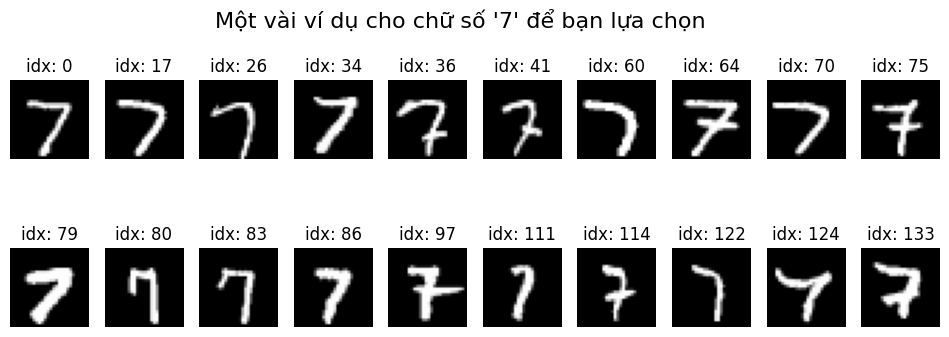


--- Tìm kiếm các ảnh cho chữ số: 2 ---
Tìm thấy 1032 ảnh. Dưới đây là một vài chỉ số bạn có thể dùng:
[1, 35, 38, 43, 47, 72, 77, 82, 106, 119, 147, 149, 172, 174, 186, 199, 208, 221, 222, 225, 236, 237, 244, 249, 256, 258, 278, 280, 285, 291, 293, 298, 303, 306, 318, 321, 326, 331, 362, 363]


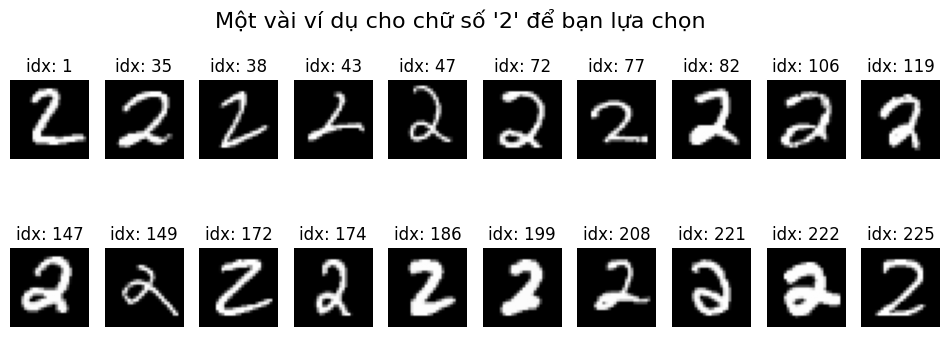


--- Tìm kiếm các ảnh cho chữ số: 4 ---
Tìm thấy 982 ảnh. Dưới đây là một vài chỉ số bạn có thể dùng:
[4, 6, 19, 24, 27, 33, 42, 48, 49, 56, 65, 67, 85, 95, 103, 109, 115, 116, 117, 121, 139, 159, 160, 163, 166, 169, 170, 198, 210, 227, 238, 247, 248, 250, 275, 287, 295, 300, 304, 308]


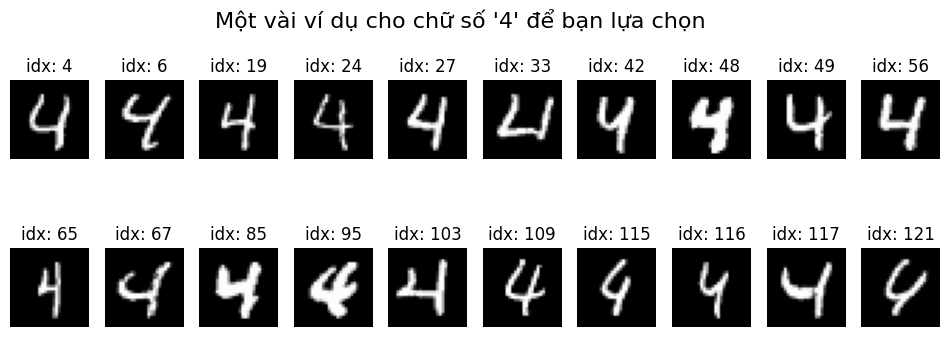

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def find_and_display_indices(dataset, digit_to_find, num_to_display=20):
    """
    Tìm và hiển thị các chỉ số (indices) và ảnh cho một chữ số cụ thể.
    """
    print(f"\n--- Tìm kiếm các ảnh cho chữ số: {digit_to_find} ---")

    # Tìm tất cả các chỉ số khớp với chữ số
    indices = [i for i, (img, label) in enumerate(dataset) if label == digit_to_find]

    print(f"Tìm thấy {len(indices)} ảnh. Dưới đây là một vài chỉ số bạn có thể dùng:")
    print(indices[:num_to_display*2]) # In ra một danh sách dài hơn để có nhiều lựa chọn

    # Hiển thị một vài ảnh đầu tiên để dễ dàng lựa chọn
    plt.figure(figsize=(12, 4))
    for i in range(num_to_display):
        if i < len(indices):
            idx = indices[i]
            img, label = dataset[idx]
            plt.subplot(2, num_to_display // 2, i + 1)
            plt.imshow(img.squeeze(), cmap='gray')
            plt.title(f"idx: {idx}")
            plt.axis('off')
    plt.suptitle(f"Một vài ví dụ cho chữ số '{digit_to_find}' để bạn lựa chọn", fontsize=16)
    plt.show()

# Tìm các chỉ số và ảnh ví dụ cho các chữ số bạn cần
find_and_display_indices(test_dataset, 7)
find_and_display_indices(test_dataset, 2)
find_and_display_indices(test_dataset, 4)

In [18]:
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Hàm nội suy tuyến tính (Linear Interpolation - Lerp)
def lerp(v1, v2, t):
    """Thực hiện nội suy tuyến tính giữa hai vector hoặc batch vector."""
    t = t.to(v1.device).unsqueeze(-1)
    return (1.0 - t) * v1.unsqueeze(0) + t * v2.unsqueeze(0)

def plot_style_interpolation_for_vae(model, dataset, digit_class, idx1, idx2, num_steps=10, save_dir="."):
    """
    Hàm nội suy đã được SỬA LẠI LẦN CUỐI để gọi đúng thuộc tính .encoder và .decoder
    """
    print(f"\nBắt đầu nội suy phong cách cho chữ số '{digit_class}' trên model VAE...")

    img1, label1 = dataset[idx1]
    img2, label2 = dataset[idx2]

    with torch.no_grad():
        # SỬA ĐỔI QUAN TRỌNG 1: Gọi model.encoder(x) thay vì model.encode(x)
        mu1, _ = model.encoder(img1.unsqueeze(0).to(DEVICE))
        mu2, _ = model.encoder(img2.unsqueeze(0).to(DEVICE))

        z1 = mu1.squeeze(0)
        z2 = mu2.squeeze(0)

        t_values = torch.linspace(0, 1, num_steps)
        interpolated_z = lerp(z1, z2, t_values).to(DEVICE)

        # SỬA ĐỔI QUAN TRỌNG 2: Gọi model.decoder(z) thay vì model.decode(z)
        generated_images = model.decoder(interpolated_z)

    # Phần vẽ kết quả giữ nguyên
    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 1.5, 2))
    for i, img in enumerate(generated_images):
        axes[i].imshow(img.cpu().squeeze(), cmap='gray')
        axes[i].axis('off')

    axes[0].set_title(f"Phong cách 1\n(idx {idx1})")
    axes[-1].set_title(f"Phong cách 2\n(idx {idx2})")
    fig.suptitle(f"Nội suy Phong cách VAE cho lớp '{digit_class}'", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])

    filename = f'{save_dir}/style_interpolation_VAE_{digit_class}_{idx1}_{idx2}.png'
    plt.savefig(filename)
    plt.close(fig)
    print(f"Đã lưu ảnh vào '{filename}'")
    display(Image(filename=filename))

# --- CÁCH SỬ DỤNG ---
# Bây giờ, khi bạn gọi hàm này với model VAE của mình, nó sẽ hoạt động.
# plot_style_interpolation_for_vae(your_vae_model, test_dataset, ...)
# --- CÁCH SỬ DỤNG ---
# Giả sử bạn có một model VAE đã huấn luyện tên là `my_vae_model`
# và bộ dữ liệu `test_dataset` đã được tải.

#
# try:
#     # Thay thế `my_vae_model` bằng tên biến chứa model VAE của bạn
#     plot_style_interpolation_for_vae(my_vae_model, test_dataset, digit_class=7, idx1=2, idx2=19, num_steps=10, save_dir=SAVE_DIR)
# except NameError:
#     print("\nLưu ý: Bạn cần thay thế 'my_vae_model' bằng biến chứa model VAE thực tế của mình để chạy ví dụ.")


--- Bắt đầu thực hiện nội suy với các chỉ số đã được kiểm tra ---

Bắt đầu nội suy phong cách cho chữ số '7' trên model VAE...
Đã lưu ảnh vào 'results_wae_annealing_v4_lpips/style_interpolation_VAE_7_17_97.png'


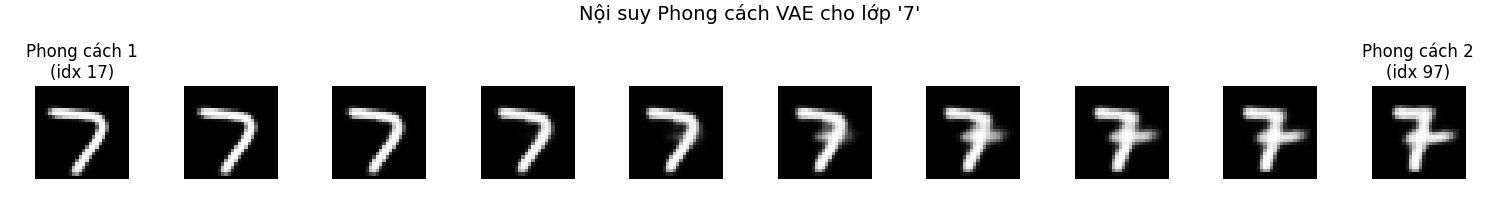


Bắt đầu nội suy phong cách cho chữ số '2' trên model VAE...
Đã lưu ảnh vào 'results_wae_annealing_v4_lpips/style_interpolation_VAE_2_1_208.png'


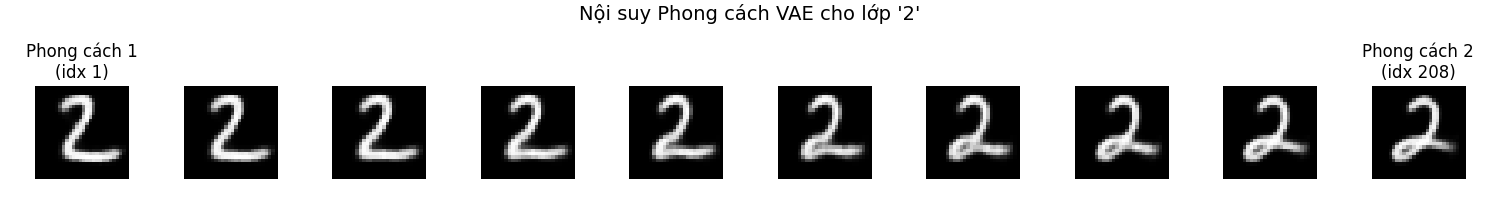


Bắt đầu nội suy phong cách cho chữ số '4' trên model VAE...
Đã lưu ảnh vào 'results_wae_annealing_v4_lpips/style_interpolation_VAE_4_4_121.png'


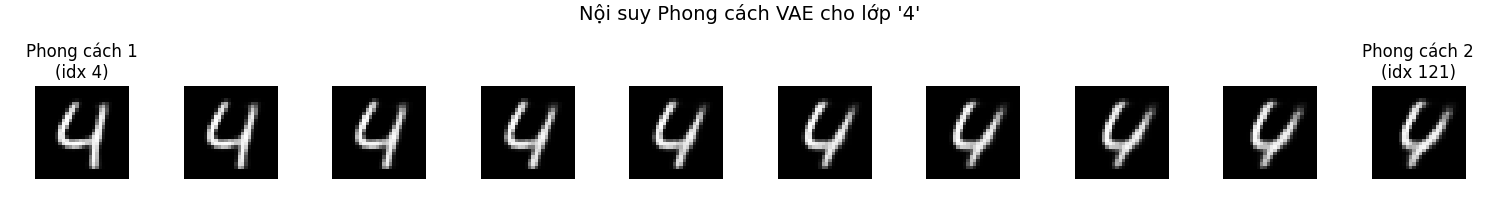

In [20]:
# Chạy lại hàm nội suy với các chỉ số MỚI và ĐÚNG
print("\n--- Bắt đầu thực hiện nội suy với các chỉ số đã được kiểm tra ---")

# Cặp số 7: (Ví dụ, hãy thay bằng cặp bạn thích)
plot_style_interpolation_for_vae(model, test_dataset, digit_class=7, idx1=17, idx2=97, num_steps=10, save_dir=SAVE_DIR)

# Cặp số 2: (Ví dụ, hãy thay bằng cặp bạn thích)
plot_style_interpolation_for_vae(model, test_dataset, digit_class=2, idx1=1, idx2=208, num_steps=10, save_dir=SAVE_DIR)

# Cặp số 4: (Ví dụ, hãy thay bằng cặp bạn thích)
plot_style_interpolation_for_vae(model, test_dataset, digit_class=4, idx1=4, idx2=121, num_steps=10, save_dir=SAVE_DIR)

In [ ]:
# ==============================================================================
#                    ADDITIONAL VISUAL TESTS FOR CS-WAE EVALUATION
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from IPython.display import Image, display
import seaborn as sns

def plot_latent_traversal(model, dataset, class_idx=7, sample_idx=17, num_dims=8, num_steps=7, save_dir="."):
    """
    Kiểm tra khả năng biểu diễn của không gian ẩn bằng cách thay đổi từng chiều một cách có hệ thống.
    """
    print(f"\n--- Bắt đầu Latent Traversal cho lớp {class_idx}, mẫu {sample_idx} ---")
    
    model.eval()
    img, label = dataset[sample_idx]
    
    with torch.no_grad():
        # Encode ảnh gốc
        mu_base, _ = model.encoder(img.unsqueeze(0).to(DEVICE))
        mu_base = F.normalize(mu_base, p=2, dim=1).squeeze(0)
        
        # Chọn các chiều đại diện để traverse
        dims_to_traverse = np.linspace(0, config["latent_dim"]-1, num_dims, dtype=int)
        
        fig, axes = plt.subplots(num_dims, num_steps, figsize=(num_steps * 1.5, num_dims * 1.5))
        
        for i, dim_idx in enumerate(dims_to_traverse):
            # Tạo các giá trị thay đổi cho chiều này
            traverse_values = torch.linspace(-2.0, 2.0, num_steps)
            
            for j, val in enumerate(traverse_values):
                # Copy vector gốc và thay đổi chiều cụ thể
                z_modified = mu_base.clone()
                z_modified[dim_idx] = val
                
                # Normalize lại để đảm bảo trên unit sphere
                z_modified = F.normalize(z_modified.unsqueeze(0), p=2, dim=1)
                
                # Decode
                generated_img = model.decoder(z_modified.to(DEVICE))
                
                # Vẽ
                axes[i, j].imshow(generated_img.cpu().squeeze(), cmap='gray')
                axes[i, j].axis('off')
                
                if j == 0:
                    axes[i, j].set_ylabel(f'Dim {dim_idx}', rotation=0, labelpad=20)
                if i == 0:
                    axes[i, j].set_title(f'{val:.1f}')
        
        plt.suptitle(f'Latent Traversal - Class {class_idx}, Sample {sample_idx}', fontsize=16)
        plt.tight_layout()
        
        filename = f'{save_dir}/latent_traversal_class{class_idx}_sample{sample_idx}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"Đã lưu Latent Traversal: {filename}")
        display(Image(filename=filename))


def plot_class_separation_analysis(model, test_loader, save_dir=".", max_samples=2000):
    """
    Phân tích sự phân tách giữa các lớp trong không gian ẩn bằng t-SNE và biểu đồ phân phối.
    """
    print(f"\n--- Bắt đầu phân tích phân tách lớp trong không gian ẩn ---")
    
    model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        sample_count = 0
        for images, batch_labels in tqdm(test_loader, desc="Extracting latent representations"):
            if sample_count >= max_samples:
                break
            
            images = images.to(DEVICE)
            mu_q, _ = model.encoder(images)
            mu_q = F.normalize(mu_q, p=2, dim=1)
            
            latents.append(mu_q.cpu().numpy())
            labels.append(batch_labels.numpy())
            sample_count += len(batch_labels)
    
    latents = np.concatenate(latents, axis=0)[:max_samples]
    labels = np.concatenate(labels, axis=0)[:max_samples]
    
    # t-SNE visualization
    print("Thực hiện t-SNE projection...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latents_2d = tsne.fit_transform(latents)
    
    # Vẽ t-SNE
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # t-SNE scatter plot
    scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    axes[0].set_title('t-SNE: Latent Space Class Separation')
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    
    # Prior centers trên t-SNE space
    with torch.no_grad():
        prior_mus = F.normalize(model.prior_mus, p=2, dim=1).cpu().numpy()
        prior_2d = tsne.fit_transform(prior_mus)
        axes[0].scatter(prior_2d[:, 0], prior_2d[:, 1], c=range(10), cmap='tab10', 
                       marker='*', s=200, edgecolor='black', label='Prior Centers')
    
    axes[0].legend()
    
    # Class distribution histogram
    axes[1].hist([latents_2d[labels == i, 0] for i in range(10)], 
                bins=30, alpha=0.7, label=[f'Class {i}' for i in range(10)])
    axes[1].set_title('Class Distribution in t-SNE Space (Dim 1)')
    axes[1].set_xlabel('t-SNE Component 1')
    axes[1].set_ylabel('Frequency')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    filename = f'{save_dir}/class_separation_analysis.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Đã lưu phân tích phân tách lớp: {filename}")
    display(Image(filename=filename))


def plot_reconstruction_quality_by_class(model, test_loader, save_dir=".", samples_per_class=5):
    """
    So sánh chất lượng tái tạo giữa các lớp khác nhau.
    """
    print(f"\n--- Phân tích chất lượng tái tạo theo từng lớp ---")
    
    model.eval()
    
    # Thu thập mẫu cho mỗi lớp
    class_samples = {i: [] for i in range(10)}
    class_originals = {i: [] for i in range(10)}
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            reconstructed, _ = model(images)
            
            for i in range(len(images)):
                label = labels[i].item()
                if len(class_samples[label]) < samples_per_class:
                    class_samples[label].append(reconstructed[i].cpu())
                    class_originals[label].append(images[i].cpu())
            
            # Kiểm tra xem đã đủ mẫu chưa
            if all(len(class_samples[i]) >= samples_per_class for i in range(10)):
                break
    
    # Vẽ comparison
    fig, axes = plt.subplots(20, samples_per_class, figsize=(samples_per_class * 2, 40))
    
    for class_idx in range(10):
        for sample_idx in range(samples_per_class):
            # Original
            row_orig = class_idx * 2
            axes[row_orig, sample_idx].imshow(class_originals[class_idx][sample_idx].squeeze(), cmap='gray')
            axes[row_orig, sample_idx].axis('off')
            if sample_idx == 0:
                axes[row_orig, sample_idx].set_ylabel(f'Class {class_idx}\nOriginal', rotation=0, labelpad=40)
            
            # Reconstructed
            row_recon = class_idx * 2 + 1
            axes[row_recon, sample_idx].imshow(class_samples[class_idx][sample_idx].squeeze(), cmap='gray')
            axes[row_recon, sample_idx].axis('off')
            if sample_idx == 0:
                axes[row_recon, sample_idx].set_ylabel('Reconstructed', rotation=0, labelpad=40)
    
    plt.suptitle('Reconstruction Quality by Class', fontsize=16)
    plt.tight_layout()
    
    filename = f'{save_dir}/reconstruction_quality_by_class.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Đã lưu phân tích chất lượng tái tạo: {filename}")
    display(Image(filename=filename))


def plot_prior_distribution_visualization(model, save_dir=".", n_samples=1000):
    """
    Trực quan hóa phân phối prior và generated samples từ mỗi class.
    """
    print(f"\n--- Trực quan hóa phân phối Prior và Generated Samples ---")
    
    model.eval()
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    with torch.no_grad():
        normalized_prior_mus = F.normalize(model.prior_mus, p=2, dim=1)
        
        for class_idx in range(10):
            # Generate samples từ prior của class này
            mu_p = normalized_prior_mus[class_idx].expand(n_samples, -1)
            rho_p = torch.full((n_samples,), model.rho_p, device=DEVICE)
            eps = sample_uniform_sphere(n_samples, config["latent_dim"], device=DEVICE)
            z_p = mobius_reparam(eps, mu_p, rho_p)
            
            # Decode để tạo ảnh
            generated_images = model.decoder(z_p)
            
            # Tạo grid của generated images
            grid_size = int(np.sqrt(min(64, n_samples)))  # 8x8 grid
            selected_images = generated_images[:grid_size**2]
            
            # Reshape thành grid
            grid = selected_images.view(grid_size, grid_size, 28, 28)
            grid = grid.permute(0, 2, 1, 3).contiguous().view(grid_size*28, grid_size*28)
            
            axes[class_idx].imshow(grid.cpu(), cmap='gray')
            axes[class_idx].set_title(f'Class {class_idx} Prior Samples')
            axes[class_idx].axis('off')
    
    plt.suptitle('Generated Samples from Class-Specific Priors', fontsize=16)
    plt.tight_layout()
    
    filename = f'{save_dir}/prior_distribution_visualization.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Đã lưu trực quan hóa phân phối prior: {filename}")
    display(Image(filename=filename))


def plot_spherical_interpolation_grid(model, save_dir=".", num_classes=4):
    """
    Tạo lưới nội suy giữa nhiều class centers để thấy transition smooth.
    """
    print(f"\n--- Tạo lưới nội suy cầu giữa các class centers ---")
    
    model.eval()
    
    # Chọn 4 classes để tạo 2x2 grid
    selected_classes = [0, 1, 3, 8]  # Có thể thay đổi
    grid_size = 7  # 7x7 grid
    
    with torch.no_grad():
        normalized_prior_mus = F.normalize(model.prior_mus, p=2, dim=1)
        
        # Lấy 4 corner points
        top_left = normalized_prior_mus[selected_classes[0]]
        top_right = normalized_prior_mus[selected_classes[1]]
        bottom_left = normalized_prior_mus[selected_classes[2]]
        bottom_right = normalized_prior_mus[selected_classes[3]]
        
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 1.5, grid_size * 1.5))
        
        for i in range(grid_size):
            for j in range(grid_size):
                # Bilinear interpolation trên sphere
                t_vertical = i / (grid_size - 1)
                t_horizontal = j / (grid_size - 1)
                
                # Interpolate top edge
                if torch.dot(top_left, top_right) > 0.99:  # Very similar, use linear
                    top_interp = F.normalize(top_left * (1 - t_horizontal) + top_right * t_horizontal, p=2, dim=0)
                else:  # Use SLERP
                    omega = torch.acos(torch.dot(top_left, top_right).clamp(-1, 1))
                    top_interp = (torch.sin((1-t_horizontal) * omega) * top_left + 
                                torch.sin(t_horizontal * omega) * top_right) / torch.sin(omega)
                
                # Interpolate bottom edge
                if torch.dot(bottom_left, bottom_right) > 0.99:
                    bottom_interp = F.normalize(bottom_left * (1 - t_horizontal) + bottom_right * t_horizontal, p=2, dim=0)
                else:
                    omega = torch.acos(torch.dot(bottom_left, bottom_right).clamp(-1, 1))
                    bottom_interp = (torch.sin((1-t_horizontal) * omega) * bottom_left + 
                                   torch.sin(t_horizontal * omega) * bottom_right) / torch.sin(omega)
                
                # Final vertical interpolation
                if torch.dot(top_interp, bottom_interp) > 0.99:
                    final_point = F.normalize(top_interp * (1 - t_vertical) + bottom_interp * t_vertical, p=2, dim=0)
                else:
                    omega = torch.acos(torch.dot(top_interp, bottom_interp).clamp(-1, 1))
                    final_point = (torch.sin((1-t_vertical) * omega) * top_interp + 
                                 torch.sin(t_vertical * omega) * bottom_interp) / torch.sin(omega)
                
                # Generate image
                generated_img = model.decoder(final_point.unsqueeze(0).to(DEVICE))
                
                axes[i, j].imshow(generated_img.cpu().squeeze(), cmap='gray')
                axes[i, j].axis('off')
                
                # Label corners
                if i == 0 and j == 0:
                    axes[i, j].set_title(f'Class {selected_classes[0]}', fontsize=8)
                elif i == 0 and j == grid_size-1:
                    axes[i, j].set_title(f'Class {selected_classes[1]}', fontsize=8)
                elif i == grid_size-1 and j == 0:
                    axes[i, j].set_title(f'Class {selected_classes[2]}', fontsize=8)
                elif i == grid_size-1 and j == grid_size-1:
                    axes[i, j].set_title(f'Class {selected_classes[3]}', fontsize=8)
    
    plt.suptitle(f'Spherical Interpolation Grid: Classes {selected_classes}', fontsize=16)
    plt.tight_layout()
    
    filename = f'{save_dir}/spherical_interpolation_grid.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Đã lưu lưới nội suy cầu: {filename}")
    display(Image(filename=filename))


print("Đã định nghĩa các hàm visual test bổ sung:")
print("1. plot_latent_traversal() - Kiểm tra ảnh hưởng của từng chiều latent")
print("2. plot_class_separation_analysis() - Phân tích phân tách lớp với t-SNE")
print("3. plot_reconstruction_quality_by_class() - So sánh chất lượng tái tạo theo lớp")
print("4. plot_prior_distribution_visualization() - Trực quan hóa prior distributions")
print("5. plot_spherical_interpolation_grid() - Lưới nội suy cầu giữa các class")

In [ ]:
# ==============================================================================
#                    THỰC HIỆN CÁC VISUAL TESTS BỔ SUNG
# ==============================================================================

print("🎨 Bắt đầu chạy các visual tests bổ sung cho CS-WAE...")
print("=" * 70)

# Test 1: Latent Traversal - Kiểm tra ảnh hưởng của từng chiều latent
print("\n🔍 Test 1: Latent Traversal Analysis")
plot_latent_traversal(model, test_dataset, class_idx=7, sample_idx=17, num_dims=6, num_steps=7, save_dir=SAVE_DIR)
plot_latent_traversal(model, test_dataset, class_idx=2, sample_idx=208, num_dims=6, num_steps=7, save_dir=SAVE_DIR)

# Test 2: Class Separation Analysis - Phân tích phân tách lớp với t-SNE
print("\n🎯 Test 2: Class Separation Analysis")
plot_class_separation_analysis(model, test_loader, save_dir=SAVE_DIR, max_samples=1500)

# Test 3: Reconstruction Quality by Class - So sánh chất lượng tái tạo
print("\n📊 Test 3: Reconstruction Quality by Class")
plot_reconstruction_quality_by_class(model, test_loader, save_dir=SAVE_DIR, samples_per_class=4)

# Test 4: Prior Distribution Visualization - Trực quan hóa phân phối prior
print("\n🎲 Test 4: Prior Distribution Visualization")
plot_prior_distribution_visualization(model, save_dir=SAVE_DIR, n_samples=800)

# Test 5: Spherical Interpolation Grid - Lưới nội suy cầu giữa các class
print("\n🌐 Test 5: Spherical Interpolation Grid")
plot_spherical_interpolation_grid(model, save_dir=SAVE_DIR)

print("\n" + "=" * 70)
print("✅ Hoàn tất tất cả visual tests bổ sung!")
print(f"📁 Tất cả kết quả đã được lưu trong thư mục: {SAVE_DIR}")
print("\nCác file ảnh đã tạo:")
print("- latent_traversal_class*.png: Phân tích traversal trong không gian ẩn")
print("- class_separation_analysis.png: Phân tích phân tách lớp với t-SNE")
print("- reconstruction_quality_by_class.png: So sánh chất lượng tái tạo theo lớp")
print("- prior_distribution_visualization.png: Trực quan hóa phân phối prior")
print("- spherical_interpolation_grid.png: Lưới nội suy cầu giữa các class centers")